1. Import and Tickers

In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# All four tickers that we need
TICKERS = {
    "usd_inr": "INRUSD=X",
    "usd_cny": "CNYUSD=X",
    "usd_idr": "IDRUSD=X",
    "usd_myr": "MYRUSD=X",
    "soybean_futures": "ZS=F",
    "brent_crude": "BZ=F",
}

print("Ticker ready:", TICKERS)
print("yfinance version:", yf.__version__)

Ticker ready: {'usd_inr': 'INRUSD=X', 'usd_cny': 'CNYUSD=X', 'usd_idr': 'IDRUSD=X', 'usd_myr': 'MYRUSD=X', 'soybean_futures': 'ZS=F', 'brent_crude': 'BZ=F'}
yfinance version: 1.3.0


2. Pull all six tickers 

In [25]:
df_raw = yf.download(
    tickers=list(TICKERS.values()),
    start="2015-01-01",
    auto_adjust=True, # adjust for dividends/splits
    progress=False, # suppress progress bar for cleaner output
)

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.to_list())
print("Index type:", type(df_raw.index))
print("Index sample:", df_raw.index[:3].to_list())
df_raw.head(3)

Shape: (2976, 30)
Columns: [('Close', 'BZ=F'), ('Close', 'CNYUSD=X'), ('Close', 'IDRUSD=X'), ('Close', 'INRUSD=X'), ('Close', 'MYRUSD=X'), ('Close', 'ZS=F'), ('High', 'BZ=F'), ('High', 'CNYUSD=X'), ('High', 'IDRUSD=X'), ('High', 'INRUSD=X'), ('High', 'MYRUSD=X'), ('High', 'ZS=F'), ('Low', 'BZ=F'), ('Low', 'CNYUSD=X'), ('Low', 'IDRUSD=X'), ('Low', 'INRUSD=X'), ('Low', 'MYRUSD=X'), ('Low', 'ZS=F'), ('Open', 'BZ=F'), ('Open', 'CNYUSD=X'), ('Open', 'IDRUSD=X'), ('Open', 'INRUSD=X'), ('Open', 'MYRUSD=X'), ('Open', 'ZS=F'), ('Volume', 'BZ=F'), ('Volume', 'CNYUSD=X'), ('Volume', 'IDRUSD=X'), ('Volume', 'INRUSD=X'), ('Volume', 'MYRUSD=X'), ('Volume', 'ZS=F')]
Index type: <class 'pandas.DatetimeIndex'>
Index sample: [Timestamp('2015-01-01 00:00:00'), Timestamp('2015-01-02 00:00:00'), Timestamp('2015-01-05 00:00:00')]


Price           Close                                                   \
Ticker           BZ=F  CNYUSD=X  IDRUSD=X  INRUSD=X  MYRUSD=X     ZS=F   
Date                                                                     
2015-01-01        NaN  0.161392  0.000081  0.015866  0.285878      NaN   
2015-01-02  56.419998  0.161392  0.000081  0.015866  0.283688  1002.50   
2015-01-05  53.110001  0.161392  0.000080  0.015803  0.281571  1039.75   

Price            High                                ...      Open            \
Ticker           BZ=F  CNYUSD=X  IDRUSD=X  INRUSD=X  ...  IDRUSD=X  INRUSD=X   
Date                                                 ...                       
2015-01-01        NaN  0.161392  0.000081  0.015866  ...  0.000081  0.015866   
2015-01-02  58.220001  0.161392  0.000081  0.015898  ...  0.000080  0.015850   
2015-01-05  56.290001  0.161392  0.000080  0.015830  ...  0.000080  0.015803   

Price                           Volume                                      \
Ticker      MYRUSD=X     ZS=F     BZ=F CNYUSD=X IDRUSD=X INRUSD=X MYRUSD=X   
Date                                                                         
2015-01-01  0.286344      NaN      NaN      0.0      0.0      0.0      0.0   
2015-01-02  0.285894  1017.75  16707.0      0.0      0.0      0.0      0.0   
2015-01-05  0.283664  1002.50  30065.0      0.0      0.0      0.0      0.0   

Price               
Ticker        ZS=F  
Date                
2015-01-01     NaN  
2015-01-02  9173.0  
2015-01-05  7451.0  

[3 rows x 30 columns]

3. Extract only Close prices, flatten the MultiIndex

In [26]:
df_close = df_raw["Close"].copy()

print("Columns after extracting Close:", df_close.columns.to_list())
print("Shape:", df_close.shape)
df_close.head(5)


Columns after extracting Close: ['BZ=F', 'CNYUSD=X', 'IDRUSD=X', 'INRUSD=X', 'MYRUSD=X', 'ZS=F']
Shape: (2976, 6)


Ticker,BZ=F,CNYUSD=X,IDRUSD=X,INRUSD=X,MYRUSD=X,ZS=F
Date,,,,,,
2015-01-01,NaN,0.161392,0.000081,0.015866,0.285878,NaN
2015-01-02,56.419998,0.161392,0.000081,0.015866,0.283688,1002.50
2015-01-05,53.110001,0.161392,0.000080,0.015803,0.281571,1039.75
2015-01-06,51.099998,0.161072,0.000079,0.015788,0.280073,1051.00
2015-01-07,51.150002,0.161238,0.000079,0.015731,0.279799,1052.75


4. Rename to meaningful names

In [27]:
df_close = df_close.rename(columns={
    "INRUSD=X": "inr_per_usd_raw",
    "CNYUSD=X": "cny_per_usd_raw",
    "IDRUSD=X": "idr_per_usd_raw",
    "MYRUSD=X": "myr_per_usd_raw",
    "ZS=F": "soybean_futures_usd",
    "BZ=F": "brent_crude_usd",
})

print(df_close.columns.to_list())
df_close.head(5)

['brent_crude_usd', 'cny_per_usd_raw', 'idr_per_usd_raw', 'inr_per_usd_raw', 'myr_per_usd_raw', 'soybean_futures_usd']


Ticker,brent_crude_usd,cny_per_usd_raw,idr_per_usd_raw,inr_per_usd_raw,myr_per_usd_raw,soybean_futures_usd
Date,,,,,,
2015-01-01,NaN,0.161392,0.000081,0.015866,0.285878,NaN
2015-01-02,56.419998,0.161392,0.000081,0.015866,0.283688,1002.50
2015-01-05,53.110001,0.161392,0.000080,0.015803,0.281571,1039.75
2015-01-06,51.099998,0.161072,0.000079,0.015788,0.280073,1051.00
2015-01-07,51.150002,0.161238,0.000079,0.015731,0.279799,1052.75


5. Flip FX direction and check null counts

In [28]:
# Flip: we want how many INR/CNY per 1 USD (rising = weakening local currency)
df_close["usd_inr"] = 1/df_close["inr_per_usd_raw"]
df_close["usd_cny"] = 1/df_close["cny_per_usd_raw"]
df_close["usd_idr"] = 1/df_close["idr_per_usd_raw"]
df_close["usd_myr"] = 1/df_close["myr_per_usd_raw"]

df_close["soybean_futures_usd"] = df_close["soybean_futures_usd"]/100

# Drop the raw columns we no longer need
df_close = df_close.drop(columns=["inr_per_usd_raw", "cny_per_usd_raw", "idr_per_usd_raw", "myr_per_usd_raw"])



In [29]:
print("Null counts:\n", df_close.isnull().sum())
print("\nSamples values (USD/INR should be ~63 in 2015, ~95 in 2026):")
print(df_close["usd_inr"].iloc[[0, -2]])

Null counts:
 Ticker
brent_crude_usd        104
soybean_futures_usd    106
usd_inr                  4
usd_cny                  5
usd_idr                  4
usd_myr                  3
dtype: int64

Samples values (USD/INR should be ~63 in 2015, ~95 in 2026):
Date
2015-01-01    63.027998
2026-06-02    95.551398
Name: usd_inr, dtype: float64


6. Resample daily to monthly

In [30]:
# Use month-end mean — more stable than last trading day for FX
# For futures, last trading day of month is more standard
df_monthly = df_close.resample("MS").agg({   # MS = month start
    "usd_inr":              "mean",
    "usd_cny":              "mean",
    "usd_idr":              "mean",
    "usd_myr":              "mean",
    "soybean_futures_usd":  "last",   # last trading day of month
    "brent_crude_usd":      "last"
})

# Rename index
df_monthly.index.name = "month_date"
df_monthly = df_monthly.reset_index()

print("Shape:", df_monthly.shape)
print("Date range:", df_monthly["month_date"].min(), "→", df_monthly["month_date"].max())
print("\nNull counts:\n", df_monthly.isnull().sum())
df_monthly.head(3)

Shape: (138, 7)
Date range: 2015-01-01 00:00:00 → 2026-06-01 00:00:00

Null counts:
 Ticker
month_date             0
usd_inr                0
usd_cny                0
usd_idr                0
usd_myr                0
soybean_futures_usd    0
brent_crude_usd        0
dtype: int64


Ticker,month_date,usd_inr,usd_cny,usd_idr,usd_myr,soybean_futures_usd,brent_crude_usd
0,2015-01-01,62.203273,6.205977,12527.772714,3.576841,9.6100,52.990002
1,2015-02-01,62.033851,6.241065,12735.150168,3.595490,10.3075,62.580002
2,2015-03-01,62.459910,6.232450,13034.045433,3.679295,9.7325,55.110001


7. Quick plot

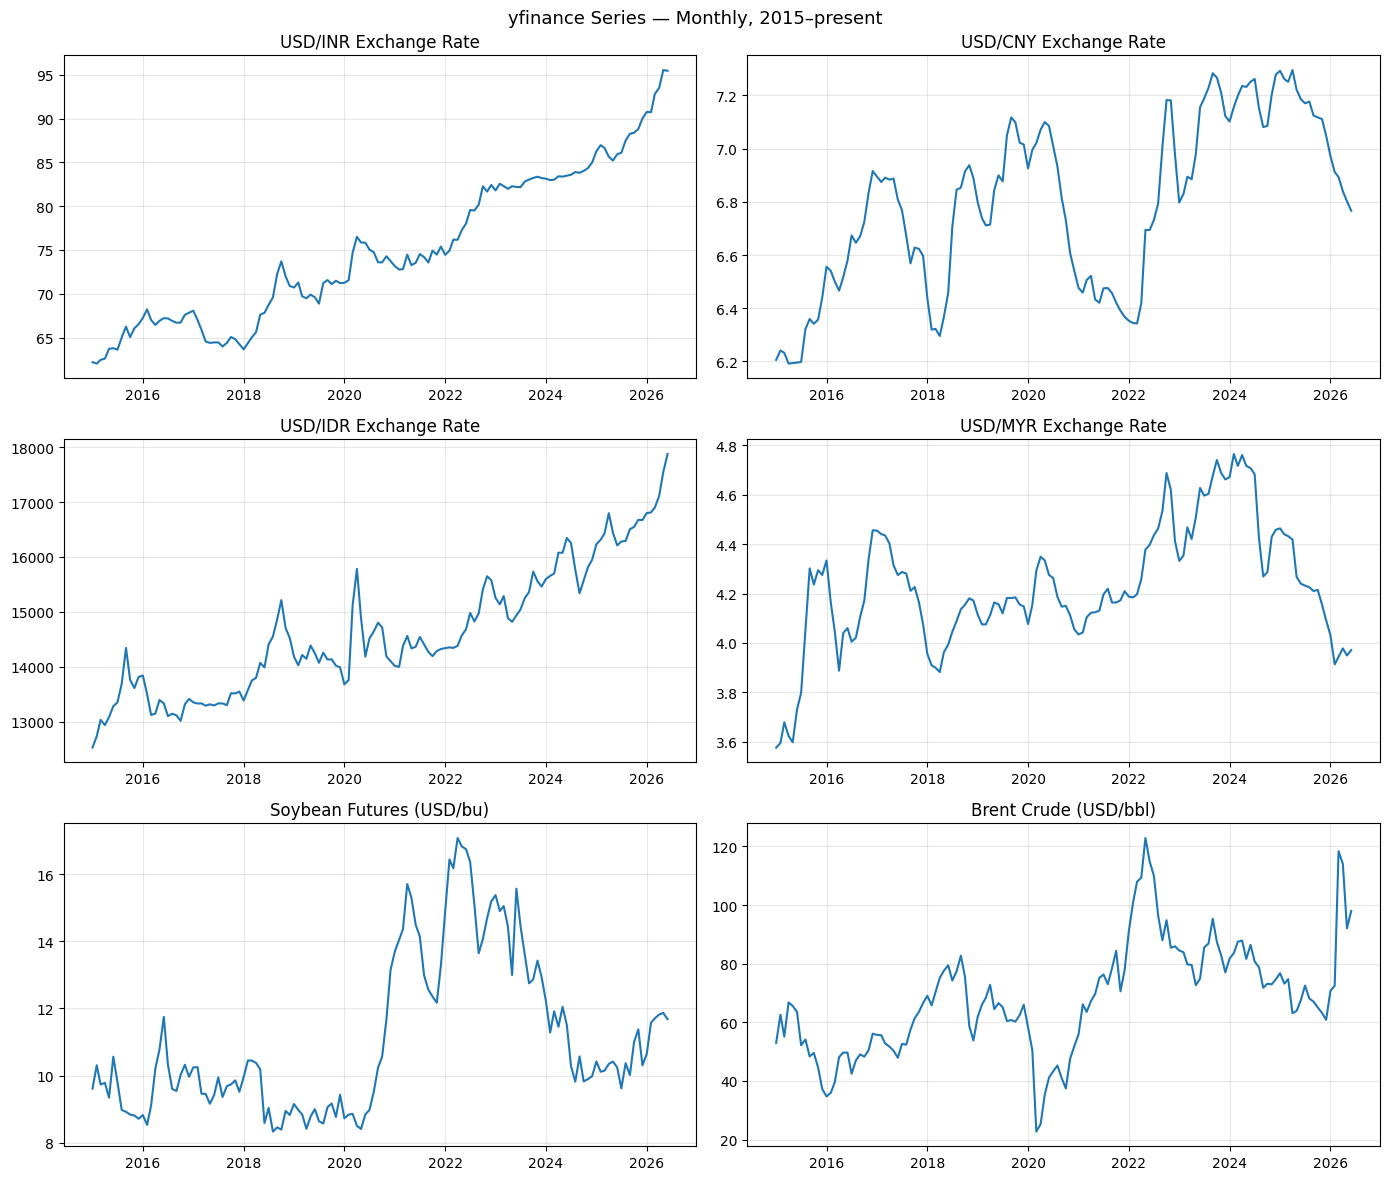

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plots = [
    ("usd_inr",             "USD/INR Exchange Rate",      axes[0,0]),
    ("usd_cny",             "USD/CNY Exchange Rate",      axes[0,1]),
    ("usd_idr",             "USD/IDR Exchange Rate",      axes[1,0]),
    ("usd_myr",             "USD/MYR Exchange Rate",      axes[1,1]),
    ("soybean_futures_usd", "Soybean Futures (USD/bu)",   axes[2,0]),
    ("brent_crude_usd",     "Brent Crude (USD/bbl)",      axes[2,1]),
]

for col, title, ax in plots:
    ax.plot(df_monthly["month_date"], df_monthly[col])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("yfinance Series — Monthly, 2015–present", fontsize=13)
plt.tight_layout()
plt.show()

## Notebook 02 — Findings & Decisions

**Source:** yfinance 1.3.0 \
**Tickers confirmed:** INRUSD=X, CNYUSD=X, ZS=F, BZ=F \
**Date range:** 2015-01-01 → 2026-05-01 \
**Shape:** 137 rows × 5 columns (after monthly resample) \
**Null values:** None

**Columns for pipeline:**
- month_date (datetime, first of month)
- usd_inr (monthly mean, INR per 1 USD)
- usd_cny (monthly mean, CNY per 1 USD)
- soybean_futures_usd (month-end last, USD/bushel)
- brent_crude_usd (month-end last, USD/barrel)

**FX direction:** Pulled as INRUSD=X and CNYUSD=X (USD per foreign unit),
flipped to USD per local currency so rising = weakening local currency.

**Resampling decisions:**
- FX rates → monthly mean (smooth daily noise)
- Futures → monthly last (standard market convention, month-end settlement)

**Key observations:**
- INR weakened ~48% vs USD from 2015–2026 (64 → 95)
- CNY more range-bound (6.2–7.4), reflects managed float policy
- Soybean futures confirm 2022 spike seen in World Bank data ✓
- Brent crude COVID crash (2020) and war spike (2022) clearly visible
- Recent Brent spike (~$115, 2026) = stronger biodiesel demand signal for CPO

In [32]:
# Sanity check — confirm direction and magnitude of all six rates
check_cols = ["month_date", "usd_inr", "usd_cny", "usd_myr", "usd_idr",
              "brent_crude_usd", "soybean_futures_usd"]

print(df_monthly[check_cols].tail(6).to_string())

Ticker month_date    usd_inr   usd_cny   usd_myr       usd_idr  brent_crude_usd  soybean_futures_usd
132    2026-01-01  90.748358  6.972552  4.031690  16800.109311        70.690002              10.6425
133    2026-02-01  90.726594  6.912190  3.913470  16810.730268        72.480003              11.5725
134    2026-03-01  92.802195  6.893395  3.944332  16902.350004       118.349998              11.7100
135    2026-04-01  93.494664  6.840145  3.978186  17110.618207       114.010002              11.8200
136    2026-05-01  95.538277  6.802405  3.949557  17547.142898        92.050003              11.8675
137    2026-06-01  95.445631  6.766467  3.971433  17875.333290        98.000000              11.6825


In [33]:
df_monthly.to_csv("nb02_fx_monthly_clean.csv", index=False)
print("Saved:", df_monthly.shape)
print(df_monthly.head(3))

Saved: (138, 7)
Ticker month_date    usd_inr   usd_cny       usd_idr   usd_myr  \
0      2015-01-01  62.203273  6.205977  12527.772714  3.576841   
1      2015-02-01  62.033851  6.241065  12735.150168  3.595490   
2      2015-03-01  62.459910  6.232450  13034.045433  3.679295   

Ticker  soybean_futures_usd  brent_crude_usd  
0                    9.6100        52.990002  
1                   10.3075        62.580002  
2                    9.7325        55.110001  
